## 1: IMPORTS

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.inspection import permutation_importance
import xgboost as xgb

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [6]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
print("Train:", train.shape, " Test:", test.shape)
train.head()

Train: (2051, 81)  Test: (879, 80)


,Id,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,SalePrice
0,109,533352170,60,RL,NaN,13517,Pave,NaN,IR1,Lvl,...,0,0,NaN,NaN,NaN,0,3,2010,WD,130500
1,544,531379050,60,RL,43.0,11492,Pave,NaN,IR1,Lvl,...,0,0,NaN,NaN,NaN,0,4,2009,WD,220000
2,153,535304180,20,RL,68.0,7922,Pave,NaN,Reg,Lvl,...,0,0,NaN,NaN,NaN,0,1,2010,WD,109000
3,318,916386060,60,RL,73.0,9802,Pave,NaN,Reg,Lvl,...,0,0,NaN,NaN,NaN,0,4,2010,WD,174000
4,255,906425045,50,RL,82.0,14235,Pave,NaN,IR1,Lvl,...,0,0,NaN,NaN,NaN,0,3,2010,WD,138500


In [7]:
print(train.dtypes.value_counts())
print("\nAntal dubbletter av Id:", train["Id"].duplicated().sum())
print("Överlapp Id train/test:", len(set(train["Id"]) & set(test["Id"])))
train["SalePrice"].describe()

object     42
int64      28
float64    11
Name: count, dtype: int64

Antal dubbletter av Id: 0
Överlapp Id train/test: 0


count      2051.000000
mean     181469.701609
std       79258.659352
min       12789.000000
25%      129825.000000
50%      162500.000000
75%      214000.000000
max      611657.000000
Name: SalePrice, dtype: float64

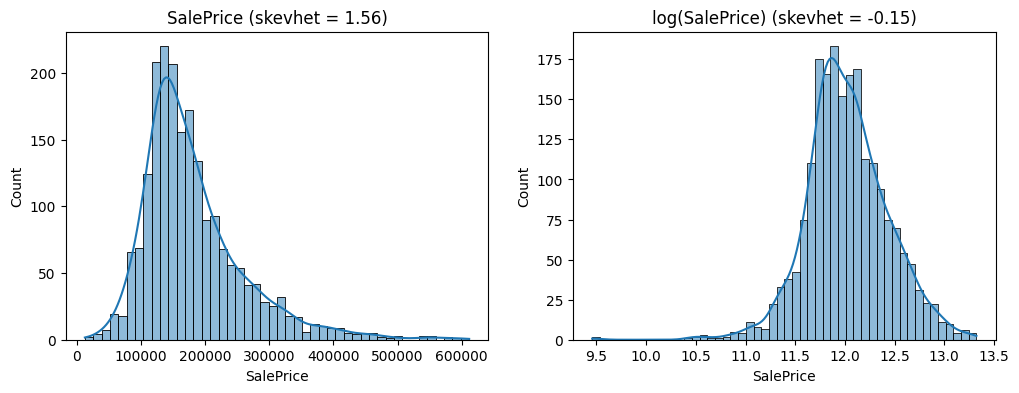

Medel: 181470  Median: 162500.0


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train["SalePrice"], kde=True, ax=ax[0])
ax[0].set_title(f"SalePrice (skevhet = {train['SalePrice'].skew():.2f})")
sns.histplot(np.log(train["SalePrice"]), kde=True, ax=ax[1])
ax[1].set_title(f"log(SalePrice) (skevhet = {np.log(train['SalePrice']).skew():.2f})")
plt.show()
print("Medel:", round(train["SalePrice"].mean()), " Median:", train["SalePrice"].median())

In [9]:
missing = train.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(1)
pd.DataFrame({"antal saknade": missing, "procent": missing_pct})

,antal saknade,procent
Pool QC,2042,99.6
Misc Feature,1986,96.8
Alley,1911,93.2
Fence,1651,80.5
Mas Vnr Type,1240,60.5
Fireplace Qu,1000,48.8
Lot Frontage,330,16.1
Garage Cond,114,5.6
Garage Yr Blt,114,5.6
Garage Finish,114,5.6


Starkast positiva korrelationer:
 Overall Qual      0.800
Gr Liv Area       0.697
Garage Area       0.650
Garage Cars       0.648
Total Bsmt SF     0.629
1st Flr SF        0.618
Year Built        0.572
Year Remod/Add    0.550
Full Bath         0.538
Garage Yr Blt     0.534
Name: SalePrice, dtype: float64

Svagast / negativa:
 Bsmt Half Bath   -0.045
MS SubClass      -0.087
Overall Cond     -0.097
Kitchen AbvGr    -0.125
Enclosed Porch   -0.136
Name: SalePrice, dtype: float64


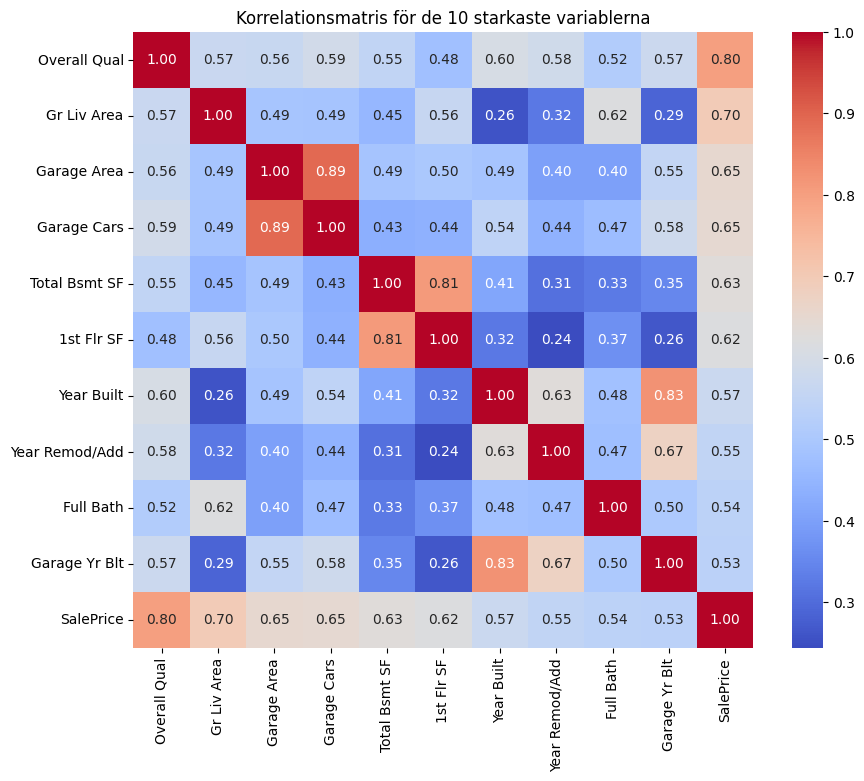

In [10]:
num_cols = train.select_dtypes(include=np.number).columns.drop(["Id", "PID"])
corr = train[num_cols].corr()["SalePrice"].drop("SalePrice").sort_values(ascending=False)
print("Starkast positiva korrelationer:\n", corr.head(10).round(3))
print("\nSvagast / negativa:\n", corr.tail(5).round(3))

top = corr.head(10).index.tolist() + ["SalePrice"]
plt.figure(figsize=(10, 8))
sns.heatmap(train[top].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Korrelationsmatris för de 10 starkaste variablerna")
plt.show()

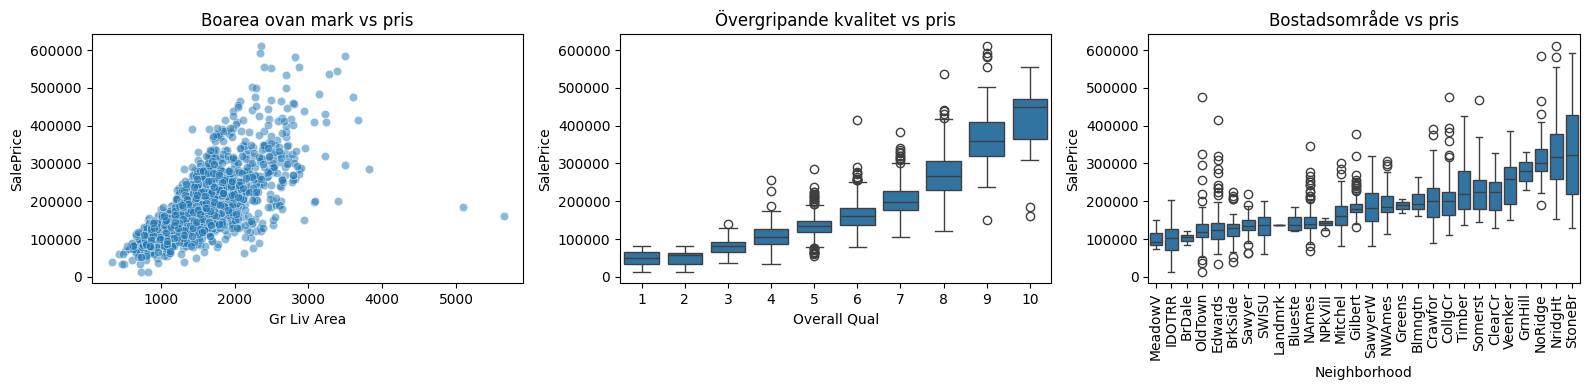

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.scatterplot(data=train, x="Gr Liv Area", y="SalePrice", ax=ax[0], alpha=0.5)
ax[0].set_title("Boarea ovan mark vs pris")
sns.boxplot(data=train, x="Overall Qual", y="SalePrice", ax=ax[1])
ax[1].set_title("Övergripande kvalitet vs pris")
order = train.groupby("Neighborhood")["SalePrice"].median().sort_values().index
sns.boxplot(data=train, x="Neighborhood", y="SalePrice", order=order, ax=ax[2])
ax[2].tick_params(axis="x", rotation=90)
ax[2].set_title("Bostadsområde vs pris")
plt.tight_layout()
plt.show()

In [12]:
outliers = train[(train["Gr Liv Area"] > 4000) & (train["SalePrice"] < 300000)]
print(outliers[["Id", "Gr Liv Area", "Overall Qual", "SalePrice"]])
train = train.drop(outliers.index).reset_index(drop=True)
print("Train efter borttagning:", train.shape)

        Id  Gr Liv Area  Overall Qual  SalePrice
960   1499         5642            10     160000
1885  2181         5095            10     183850
Train efter borttagning: (2049, 81)


In [13]:
none_cols = ["Pool QC", "Misc Feature", "Alley", "Fence", "Fireplace Qu", "Mas Vnr Type",
            "Garage Type", "Garage Finish", "Garage Qual", "Garage Cond",
            "Bsmt Qual", "Bsmt Cond", "Bsmt Exposure", "BsmtFin Type 1", "BsmtFin Type 2"]
zero_cols = ["Mas Vnr Area", "BsmtFin SF 1", "BsmtFin SF 2", "Bsmt Unf SF", "Total Bsmt SF",
            "Bsmt Full Bath", "Bsmt Half Bath", "Garage Cars", "Garage Area"]

def clean(df):
    df = df.copy()
    for c in none_cols:
        df[c] = df[c].fillna("None")
    for c in zero_cols:
        df[c] = df[c].fillna(0)
    df["Garage Yr Blt"] = df["Garage Yr Blt"].fillna(df["Year Built"])
    df.loc[df["Garage Yr Blt"] > 2010, "Garage Yr Blt"] = df["Year Built"]
    for c in df.select_dtypes(include="object").columns:
        df[c] = df[c].str.strip()
    df["MS SubClass"] = df["MS SubClass"].astype(str)
    df["Mo Sold"] = df["Mo Sold"].astype(str)
    return df

train_c = clean(train)
test_c = clean(test)
print("Saknade värden kvar i train:\n", train_c.isna().sum()[train_c.isna().sum() > 0])

Saknade värden kvar i train:
 Lot Frontage    330
dtype: int64


## 2: Codning, Feature engineering, Pipeline and Model comparison

In [14]:
qual_map = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
qual_cols = ["Exter Qual", "Exter Cond", "Bsmt Qual", "Bsmt Cond", "Heating QC",
            "Kitchen Qual", "Fireplace Qu", "Garage Qual", "Garage Cond", "Pool QC"]
exposure_map = {"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4}
finish_map = {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6}
garfin_map = {"None": 0, "Unf": 1, "RFn": 2, "Fin": 3}

def encode_ordinal(df):
    df = df.copy()
    for c in qual_cols:
        df[c] = df[c].map(qual_map)
    df["Bsmt Exposure"] = df["Bsmt Exposure"].map(exposure_map)
    df["BsmtFin Type 1"] = df["BsmtFin Type 1"].map(finish_map)
    df["BsmtFin Type 2"] = df["BsmtFin Type 2"].map(finish_map)
    df["Garage Finish"] = df["Garage Finish"].map(garfin_map)
    return df

train_o = encode_ordinal(train_c)
test_o = encode_ordinal(test_c)
train_o[qual_cols].head()

,Exter Qual,Exter Cond,Bsmt Qual,Bsmt Cond,Heating QC,Kitchen Qual,Fireplace Qu,Garage Qual,Garage Cond,Pool QC
0,4,3,3,3,5,4,0,3,3,0
1,4,3,4,3,5,4,3,3,3,0
2,3,4,3,3,3,4,0,3,3,0
3,3,3,4,3,4,3,0,3,3,0
4,3,3,2,4,3,3,0,3,3,0


In [15]:
def add_features(df):
    df = df.copy()
    df["TotalSF"] = df["Total Bsmt SF"] + df["1st Flr SF"] + df["2nd Flr SF"]
    df["TotalFinishedSF"] = df["BsmtFin SF 1"] + df["BsmtFin SF 2"] + df["Gr Liv Area"]
    df["TotalBath"] = (df["Full Bath"] + 0.5 * df["Half Bath"]
                       + df["Bsmt Full Bath"] + 0.5 * df["Bsmt Half Bath"])
    df["HouseAge"] = (df["Yr Sold"] - df["Year Built"]).clip(lower=0)
    df["RemodAge"] = (df["Yr Sold"] - df["Year Remod/Add"]).clip(lower=0)
    df["IsRemodeled"] = (df["Year Remod/Add"] != df["Year Built"]).astype(int)
    df["IsNew"] = (df["Yr Sold"] == df["Year Built"]).astype(int)
    df["TotalPorchSF"] = (df["Open Porch SF"] + df["Enclosed Porch"] + df["3Ssn Porch"]
                        + df["Screen Porch"] + df["Wood Deck SF"])
    df["Qual_x_LivArea"] = df["Overall Qual"] * df["Gr Liv Area"]
    df["Qual_x_TotalSF"] = df["Overall Qual"] * df["TotalSF"]
    df["OverallScore"] = df["Overall Qual"] * df["Overall Cond"]
    df["ExterScore"] = df["Exter Qual"] * df["Exter Cond"]
    df["KitchenScore"] = df["Kitchen Qual"] * df["Kitchen AbvGr"]
    df["GarageScore"] = df["Garage Qual"] * df["Garage Area"]
    df["HasPool"] = (df["Pool Area"] > 0).astype(int)
    df["Has2ndFloor"] = (df["2nd Flr SF"] > 0).astype(int)
    df["HasGarage"] = (df["Garage Area"] > 0).astype(int)
    df["HasBsmt"] = (df["Total Bsmt SF"] > 0).astype(int)
    df["HasFireplace"] = (df["Fireplaces"] > 0).astype(int)
    return df

train_fe = add_features(train_o)
test_fe = add_features(test_o)
new_feats = [c for c in train_fe.columns if c not in train_o.columns]
train_fe[new_feats + ["SalePrice"]].corr()["SalePrice"].drop("SalePrice").sort_values(ascending=False).round(3)

Qual_x_TotalSF     0.921
Qual_x_LivArea     0.873
TotalSF            0.830
TotalFinishedSF    0.763
GarageScore        0.665
TotalBath          0.633
ExterScore         0.598
OverallScore       0.566
HasFireplace       0.486
KitchenScore       0.459
TotalPorchSF       0.410
IsNew              0.260
HasGarage          0.231
HasBsmt            0.157
Has2ndFloor        0.079
HasPool            0.028
IsRemodeled       -0.048
RemodAge          -0.552
HouseAge          -0.572
Name: SalePrice, dtype: float64

In [16]:
y = np.log(train_fe["SalePrice"])
drop_cols = ["Id", "PID", "SalePrice"]
X = train_fe.drop(columns=drop_cols)
X_test = test_fe.drop(columns=["Id", "PID"])

cat_features = X.select_dtypes(include="object").columns.tolist()
num_features = X.select_dtypes(include=np.number).columns.tolist()

skewness = X[num_features].skew().abs()
skewed_features = skewness[skewness > 0.75].index.tolist()
for c in skewed_features:
    X[c] = np.log1p(X[c].clip(lower=0))
    X_test[c] = np.log1p(X_test[c].clip(lower=0))

print(f"{len(num_features)} numeriska, {len(cat_features)} kategoriska, {len(skewed_features)} log-transformerade")

67 numeriska, 30 kategoriska, 38 log-transformerade


In [17]:
def make_preprocessor(num_features, cat_features):
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=10, sparse_output=False)),
    ])
    return ColumnTransformer([
        ("num", num_pipe, num_features),
        ("cat", cat_pipe, cat_features),
    ])

preprocessor = make_preprocessor(num_features, cat_features)

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate(model, X, y, name):
    prep = make_preprocessor(X.select_dtypes(include=np.number).columns.tolist(),
                            X.select_dtypes(include="object").columns.tolist())
    pipe = Pipeline([("prep", prep), ("model", model)])
    pred_log = cross_val_predict(pipe, X, y, cv=kf)
    rmse_log = np.sqrt(mean_squared_error(y, pred_log))
    mse_price = mean_squared_error(np.exp(y), np.exp(pred_log))
    scores = -cross_val_score(pipe, X, y, cv=kf, scoring="neg_root_mean_squared_error")
    return {"modell": name, "RMSE (log)": rmse_log, "std över folds": scores.std(),
            "MSE (pris)": mse_price, "RMSE (pris, $)": np.sqrt(mse_price)}

In [18]:
baseline = [
    evaluate(DummyRegressor(strategy="median"), X, y, "Baslinje: medianpris"),
    evaluate(LinearRegression(), X[["Gr Liv Area", "Overall Qual"]], y, "Baslinje: LinReg (2 variabler)"),
]
pd.DataFrame(baseline).round(4)

,modell,RMSE (log),std över folds,MSE (pris),"RMSE (pris, $)"
0,Baslinje: medianpris,0.4128,0.0080,6.666215e+09,81646.8915
1,Baslinje: LinReg (2 variabler),0.1983,0.0073,1.282222e+09,35808.1261


In [19]:
models = {
    "Linjär regression (OLS)": LinearRegression(),
    "Ridge": Ridge(alpha=10),
    "Lasso": Lasso(alpha=0.0005, max_iter=50000),
    "SVR (RBF)": SVR(kernel="rbf", C=10, epsilon=0.01, gamma=0.0005),
    "Neuralt nätverk (MLP)": MLPRegressor(hidden_layer_sizes=(64, 32), alpha=1.0,
                                        learning_rate_init=0.001, max_iter=2000,
                                        early_stopping=True, random_state=RANDOM_STATE),
    "Beslutsträd": DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1),
    "AdaBoost": AdaBoostRegressor(DecisionTreeRegressor(max_depth=6), n_estimators=300,
                                learning_rate=0.05, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=1500, learning_rate=0.03, max_depth=3,
                                                subsample=0.8, random_state=RANDOM_STATE),
    "XGBoost": xgb.XGBRegressor(n_estimators=1500, learning_rate=0.03, max_depth=3,
                                subsample=0.8, colsample_bytree=0.5, random_state=RANDOM_STATE, n_jobs=-1),
}

results = baseline.copy()
for name, model in models.items():
    results.append(evaluate(model, X, y, name))
    print(f"{name:28s} klar")

results_df = pd.DataFrame(results).sort_values("RMSE (log)").reset_index(drop=True)
results_df.round(4)

Linjär regression (OLS)      klar
Ridge                        klar
Lasso                        klar
SVR (RBF)                    klar
Neuralt nätverk (MLP)        klar
Beslutsträd                  klar
Random Forest                klar
AdaBoost                     klar
Gradient Boosting            klar
XGBoost                      klar


,modell,RMSE (log),std över folds,MSE (pris),"RMSE (pris, $)"
0,SVR (RBF),0.1140,0.0121,3.361840e+08,18335.3208
1,Ridge,0.1180,0.0095,3.953401e+08,19883.1623
2,Lasso,0.1183,0.0104,3.997657e+08,19994.1405
3,XGBoost,0.1190,0.0083,3.891602e+08,19727.1447
4,Gradient Boosting,0.1198,0.0080,3.978740e+08,19946.7795
5,Linjär regression (OLS),0.1251,0.0108,4.271440e+08,20667.4614
6,Random Forest,0.1369,0.0058,5.855849e+08,24198.8619
7,AdaBoost,0.1429,0.0066,6.191246e+08,24882.2142
8,Neuralt nätverk (MLP),0.1774,0.0223,1.084831e+09,32936.7797
9,Beslutsträd,0.1980,0.0125,1.271081e+09,35652.2196


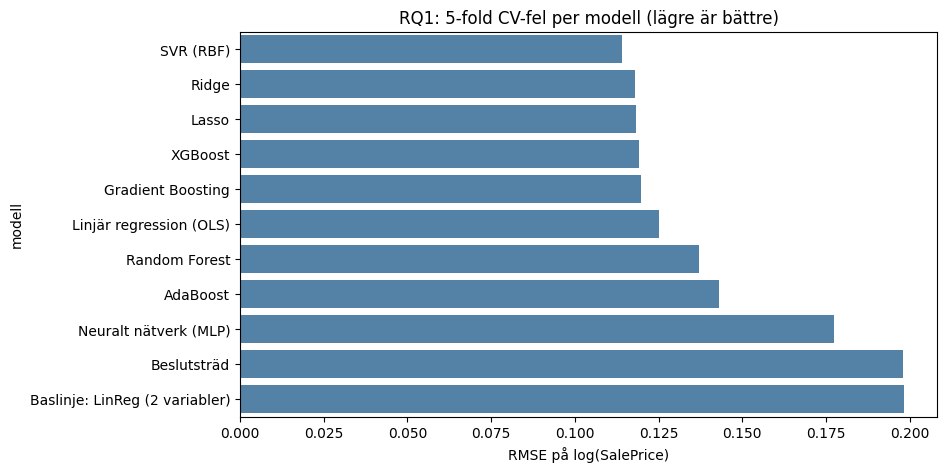

In [20]:
plt.figure(figsize=(9, 5))
plot_df = results_df[~results_df["modell"].str.startswith("Baslinje: median")]
sns.barplot(data=plot_df, y="modell", x="RMSE (log)", color="steelblue")
plt.title("RQ1: 5-fold CV-fel per modell (lägre är bättre)")
plt.xlabel("RMSE på log(SalePrice)")
plt.show()

In [21]:
raw = clean(train)
X_raw = raw.drop(columns=drop_cols)
y_raw = np.log(raw["SalePrice"])
rq2 = [
    evaluate(Ridge(alpha=10), X_raw, y_raw, "Ridge – utan FE"),
    evaluate(xgb.XGBRegressor(n_estimators=1500, learning_rate=0.03, max_depth=3, subsample=0.8,
                            colsample_bytree=0.5, random_state=RANDOM_STATE, n_jobs=-1),
            X_raw, y_raw, "XGBoost – utan FE"),
]
rq2 += [r for r in results if r["modell"] in ["Ridge", "XGBoost"]]
pd.DataFrame(rq2).round(4)

,modell,RMSE (log),std över folds,MSE (pris),"RMSE (pris, $)"
0,Ridge – utan FE,0.1217,0.0134,4.218646e+08,20539.3433
1,XGBoost – utan FE,0.1184,0.0099,3.823733e+08,19554.3673
2,Ridge,0.1180,0.0095,3.953401e+08,19883.1623
3,XGBoost,0.1190,0.0083,3.891602e+08,19727.1447


In [22]:
ridge_grid = GridSearchCV(Pipeline([("prep", preprocessor), ("model", Ridge())]),
                        {"model__alpha": [1, 3, 5, 10, 15, 20, 30, 50]},
                        cv=kf, scoring="neg_root_mean_squared_error")
ridge_grid.fit(X, y)
print("Ridge bästa alpha:", ridge_grid.best_params_, " RMSE:", round(-ridge_grid.best_score_, 4))

lasso_grid = GridSearchCV(Pipeline([("prep", preprocessor), ("model", Lasso(max_iter=50000))]),
                        {"model__alpha": [0.0001, 0.0003, 0.0005, 0.001, 0.002, 0.005]},
                        cv=kf, scoring="neg_root_mean_squared_error")
lasso_grid.fit(X, y)
print("Lasso bästa alpha:", lasso_grid.best_params_, " RMSE:", round(-lasso_grid.best_score_, 4))

xgb_grid = GridSearchCV(Pipeline([("prep", preprocessor),
                                ("model", xgb.XGBRegressor(n_estimators=1500, learning_rate=0.03,
                                                            subsample=0.8, random_state=RANDOM_STATE,
                                                            n_jobs=-1))]),
                        {"model__max_depth": [2, 3, 4], "model__colsample_bytree": [0.3, 0.5]},
                        cv=kf, scoring="neg_root_mean_squared_error")
xgb_grid.fit(X, y)
print("XGBoost bästa:", xgb_grid.best_params_, " RMSE:", round(-xgb_grid.best_score_, 4))

Ridge bästa alpha: {'model__alpha': 20}  RMSE: 0.1173
Lasso bästa alpha: {'model__alpha': 0.0003}  RMSE: 0.1176
XGBoost bästa: {'model__colsample_bytree': 0.3, 'model__max_depth': 4}  RMSE: 0.1172


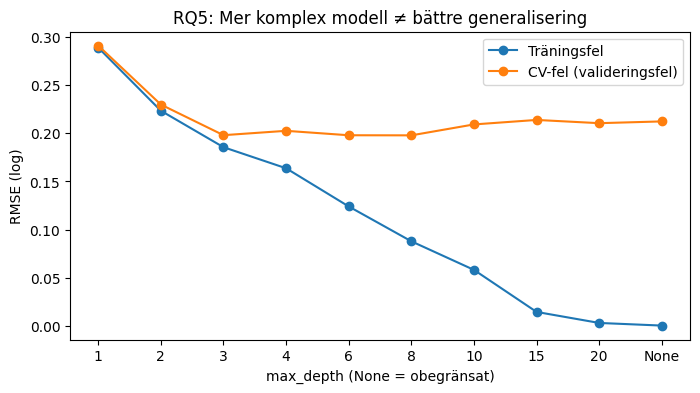

,max_depth,träningsfel,CV-fel
0,1,0.2886,0.2907
1,2,0.2232,0.2296
2,3,0.1854,0.1978
3,4,0.1635,0.2023
4,6,0.1239,0.1977
5,8,0.0878,0.1976
6,10,0.0582,0.2089
7,15,0.0146,0.2136
8,20,0.0032,0.2102
9,None,0.0005,0.2121


In [23]:
depths = [1, 2, 3, 4, 6, 8, 10, 15, 20, None]
train_err, cv_err = [], []
for d in depths:
    pipe = Pipeline([("prep", preprocessor),
                    ("model", DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE))])
    cv_err.append(-cross_val_score(pipe, X, y, cv=kf, scoring="neg_root_mean_squared_error").mean())
    pipe.fit(X, y)
    train_err.append(np.sqrt(mean_squared_error(y, pipe.predict(X))))

labels = [str(d) for d in depths]
plt.figure(figsize=(8, 4))
plt.plot(labels, train_err, marker="o", label="Träningsfel")
plt.plot(labels, cv_err, marker="o", label="CV-fel (valideringsfel)")
plt.xlabel("max_depth (None = obegränsat)")
plt.ylabel("RMSE (log)")
plt.title("RQ5: Mer komplex modell ≠ bättre generalisering")
plt.legend()
plt.show()
pd.DataFrame({"max_depth": labels, "träningsfel": train_err, "CV-fel": cv_err}).round(4)

## 3: Interpretation, Final Model and Submission

Lasso behöll 142 av 252 variabler


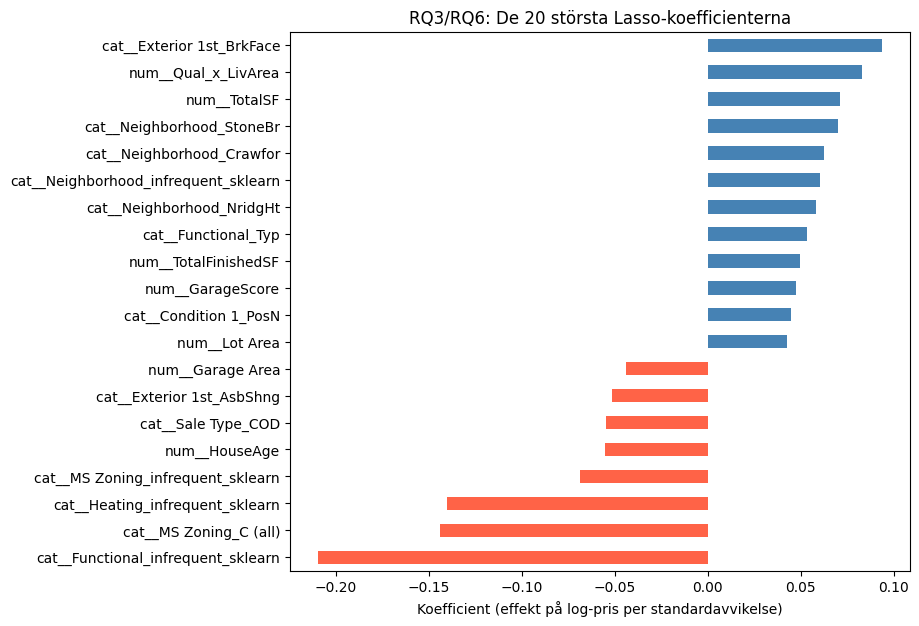

In [24]:
best_lasso = lasso_grid.best_estimator_
feat_names = best_lasso.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(best_lasso.named_steps["model"].coef_, index=feat_names)
print(f"Lasso behöll {(coefs != 0).sum()} av {len(coefs)} variabler")

top_coefs = coefs[coefs != 0].sort_values(key=abs, ascending=False).head(20)
plt.figure(figsize=(8, 7))
top_coefs.sort_values().plot(kind="barh", color=["tomato" if v < 0 else "steelblue" for v in top_coefs.sort_values()])
plt.title("RQ3/RQ6: De 20 största Lasso-koefficienterna")
plt.xlabel("Koefficient (effekt på log-pris per standardavvikelse)")
plt.show()

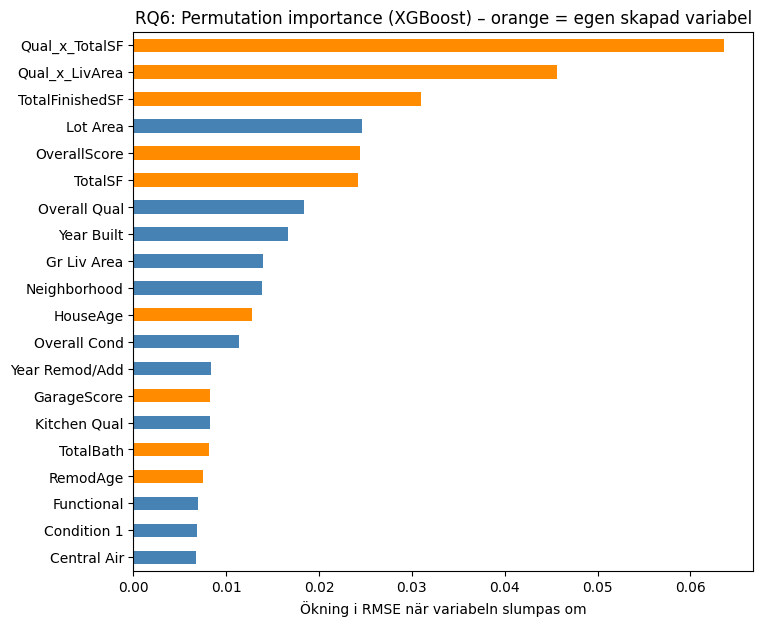

In [25]:
best_xgb = xgb_grid.best_estimator_
perm = permutation_importance(best_xgb, X, y, n_repeats=5, random_state=RANDOM_STATE,
                            scoring="neg_root_mean_squared_error", n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 7))
perm_imp.head(20).sort_values().plot(kind="barh", color=["darkorange" if c in new_feats else "steelblue"
                                                        for c in perm_imp.head(20).sort_values().index])
plt.title("RQ6: Permutation importance (XGBoost) – orange = egen skapad variabel")
plt.xlabel("Ökning i RMSE när variabeln slumpas om")
plt.show()

In [26]:
class AverageEnsemble:
    def __init__(self, models, weights):
        self.models, self.weights = models, weights
    def fit(self, X, y):
        for m in self.models:
            m.fit(X, y)
        return self
    def predict(self, X):
        return sum(w * m.predict(X) for m, w in zip(self.models, self.weights))

from sklearn.base import clone

svr_pipe = Pipeline([("prep", preprocessor),
                    ("model", SVR(kernel="rbf", C=10, epsilon=0.01, gamma=0.0005))])

def make_ensemble():
    return AverageEnsemble(
        [clone(ridge_grid.best_estimator_), clone(xgb_grid.best_estimator_), clone(svr_pipe)],
        [1/3, 1/3, 1/3])

oof = np.zeros(len(y))
fold_rmse = []
for tr_idx, va_idx in kf.split(X):
    ens = make_ensemble().fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof[va_idx] = ens.predict(X.iloc[va_idx])
    fold_rmse.append(np.sqrt(mean_squared_error(y.iloc[va_idx], oof[va_idx])))

print("Ensemble RMSE (log):", round(np.sqrt(mean_squared_error(y, oof)), 4), "+/-", round(np.std(fold_rmse), 4))
print("Ensemble MSE (pris):", f"{mean_squared_error(np.exp(y), np.exp(oof)):.3e}")
print("Ensemble RMSE (pris): $", round(np.sqrt(mean_squared_error(np.exp(y), np.exp(oof)))))

Ensemble RMSE (log): 0.1124 +/- 0.0103
Ensemble MSE (pris): 3.391e+08
Ensemble RMSE (pris): $ 18415


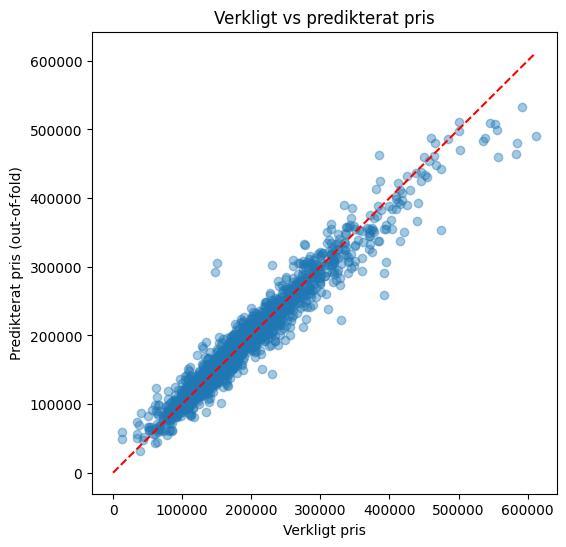

In [27]:
plt.figure(figsize=(6, 6))
plt.scatter(np.exp(y), np.exp(oof), alpha=0.4)
lims = [0, np.exp(y).max()]
plt.plot(lims, lims, "r--")
plt.xlabel("Verkligt pris")
plt.ylabel("Predikterat pris (out-of-fold)")
plt.title("Verkligt vs predikterat pris")
plt.show()

In [28]:
final_model = make_ensemble().fit(X, y)
test_pred = np.exp(final_model.predict(X_test))

submission = pd.DataFrame({"Id": test["Id"], "SalePrice": test_pred})
submission.to_csv("submission.csv", index=False)
print(submission.shape)
print(submission["SalePrice"].describe())
submission.head()

(879, 2)
count       879.000000
mean     179134.153169
std       77175.323027
min       41996.267274
25%      128668.064096
50%      157847.175764
75%      211728.227101
max      732745.816969
Name: SalePrice, dtype: float64


,Id,SalePrice
0,2658,127356.574120
1,2718,153144.421916
2,2414,217196.827922
3,1989,103765.076014
4,625,175085.238225
